## Melbourne Property Intelligence: Key Insights & Investment Takeaways 

This notebook summarises findings from the rental yield analysis, interest rate sensitivity scenarios, and rental demand proxies to derive suburb-level investment insights across Melbourne. Rather than presenting additional exploratory analysis, this section focuses on translating results into clear, decision-relevant takeaways for property investors operating under different risk and return profiles.

### **Insight 1**: High rental yields are concentrated in outer and middle suburbs 

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 

merged = pd.read_csv("../data/processed/suburb_house_rental_yield.csv")
merged.head()

,region,suburb,median_rent,property_type,median_price,sales_count,gross_yield,gross_yield_pct
0,Inner Melbourne,Armadale,1100.0,3 Bed House,2588000.0,20,0.022102,2.210201
1,Inner Melbourne,Carlton North,930.0,3 Bed House,1730000.0,20,0.027954,2.795376
2,Inner Melbourne,East Melbourne,1200.0,3 Bed House,1696000.0,2,0.036792,3.679245
3,Inner Melbourne,Elwood,1000.0,3 Bed House,2542500.0,20,0.020452,2.045231
4,Inner Melbourne,Fitzroy,1100.0,3 Bed House,1600000.0,24,0.035750,3.575000


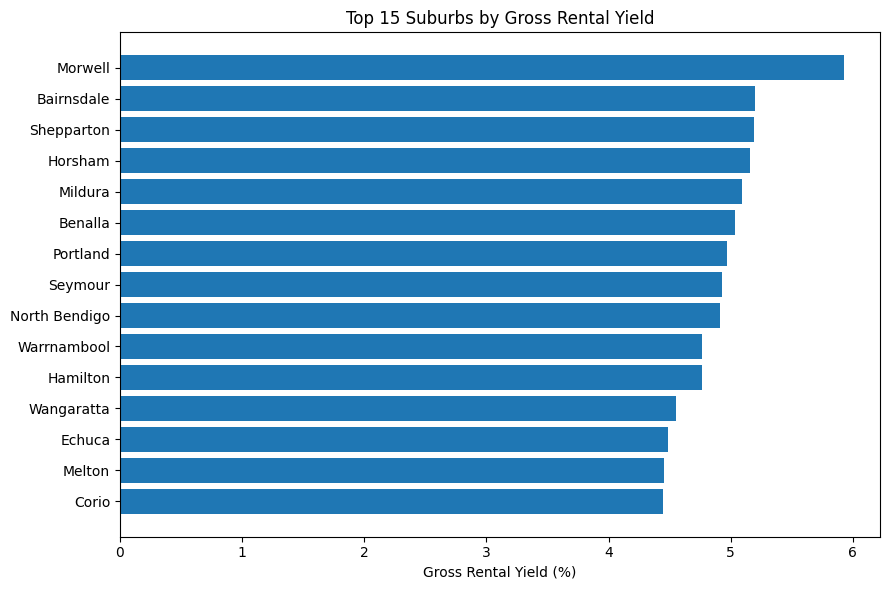

In [4]:
#Top 15 suburbs by gross rental yields
top_yield_suburbs = (merged.sort_values("gross_yield_pct",ascending=False).head(15))

plt.figure(figsize=(9,6))
plt.barh(
    top_yield_suburbs["suburb"],
    top_yield_suburbs["gross_yield_pct"]
)

plt.gca().invert_yaxis()
plt.xlabel("Gross Rental Yield (%)")
plt.title("Top 15 Suburbs by Gross Rental Yield")
plt.tight_layout()
plt.show()

In [6]:
top_yield_table = top_yield_suburbs[
    ["suburb","median_price","median_rent","gross_yield_pct"]
].reset_index(drop=True)

top_yield_table["gross_yield_pct"] = (
    top_yield_table["gross_yield_pct"]
).round(2)

top_yield_table

,suburb,median_price,median_rent,gross_yield_pct
0,Morwell,351000.0,400.0,5.93
1,Bairnsdale,450000.0,450.0,5.20
2,Shepparton,470500.0,470.0,5.19
3,Horsham,413100.0,410.0,5.16
4,Mildura,485000.0,475.0,5.09
5,Benalla,465000.0,450.0,5.03
6,Portland,445000.0,425.0,4.97
7,Seymour,443000.0,420.0,4.93
8,North Bendigo,497500.0,470.0,4.91
9,Warrnambool,600000.0,550.0,4.77


**Interpretation**

The highest gross rental yields are predominantly observed in regional and outer markets rather than Melbourne's inner suburbs. These locations exhibit a common pricing dynamic: relatively low purchase prices combined with steady rental demand, resulting in gross yields in the range of approximately 4.5% to 6%. 

This pattern highlights the trade-off faced by income-focused investors. While these suburbs offer stronger cash flow characteristics, they are generally located further from Melbourne's CBD and may carry higher exposureto regional econmic and slower long-term capital growth. As a result, high rental yield alone should not be interpreted as superior investment quality, but rather as one component within a broader risk-return assessment that also considers demand stability and growth prospects. 

### **Insight 2**: Inner-city suburbs show structurally lower yields but stronger demand signals 

In [8]:
demand_yield = pd.read_csv("../data/processed/yield_demand_lga_2025.csv")
band_summary = pd.read_csv("../data/processed/yield_demand_band_summary.csv")

demand_yield.head(), band_summary

(          lga  avg_gross_yield_pct  suburb_count  active_bonds    demand_band
 0     BAW BAW             4.025806             1          3447     Low Demand
 1  BOROONDARA             1.596056             3         18361    High Demand
 2    BRIMBANK             3.576936             3         16084    High Demand
 3    CAMPASPE             4.490501             1          2031     Low Demand
 4    CARDINIA             4.074627             1          8666  Medium Demand,
      demand_band  avg_yield_pct  avg_active_bonds  lga_count
 0     Low Demand       4.483657       1759.000000         14
 1  Medium Demand       3.633669       9801.692308         13
 2    High Demand       2.988001      22857.142857         14)

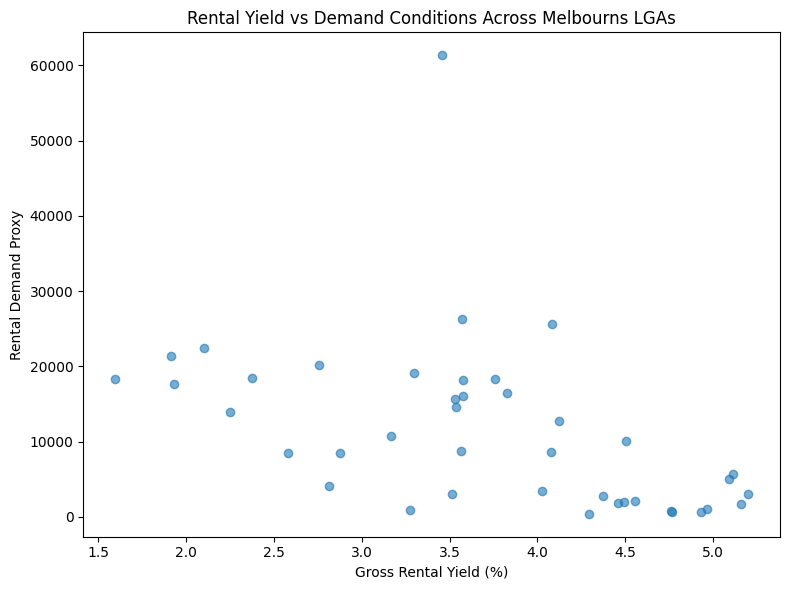

In [ ]:
#scatter plot for yield vs demand 
plt.figure(figsize=(8,6))
plt.scatter(
    demand_yield["avg_gross_yield_pct"],
    demand_yield["active_bonds"], #using active bonds as demand proxy (numerical to numerical better for scatter)
    alpha=0.6
)

plt.xlabel("Gross Rental Yield (%)")
plt.ylabel("Rental Demand Proxy")
plt.title("Rental Yield vs Demand Conditions Across Melbourns LGAs")
plt.tight_layout()
plt.show()

In [14]:
band_summary.rename(columns={
    "demand_band": "Demand Band",
    "avg_yield_pct": "Average Gross Yield (%)",
    "avg_active_bonds": "Average Active Bonds",
    "lga_count": "Number of LGAs"
}, inplace=True)

band_summary["Average Gross Yield (%)"] = (band_summary["Average Gross Yield (%)"]).round(2)

band_summary["Average Active Bonds"] = (band_summary["Average Active Bonds"]).round(0).astype(int)

band_summary

,Demand Band,Average Gross Yield (%),Average Active Bonds,Number of LGAs
0,Low Demand,4.48,1759,14
1,Medium Demand,3.63,9802,13
2,High Demand,2.99,22857,14


**Interpretation**

The analysis reveals a clear inverse relationship between rental yield and rental demand intensity across Melbourne LGAs. Areas classified as high demand exhibit substantially lower gross rental yields but significantly higher levels of active rental bonds, indicating more competitive rental markets. 

This pattern reflects the pricing dynamics of inner and well-connected metro areas, where strong tenant demand and higher property prices compress income yields. For investors, this suggests that lower yields in high-demand locations may be offset by greater rental stability and reduced vacancy risk, while higher yield areas involve a trade off between income return and demand resilience. 


### **Insight 3**: Interest rate increases disproportionately affect low-yield suburbs 

In [20]:
spreads = pd.read_csv("../data/processed/suburb_yield_rate_spreads.csv")

In [24]:
insight3_table = (
    spreads
    .groupby("yield_quartile")[
        ["spread_low_rate", "spread_current_rate", "spread_high_rate"]
    ]
    .mean()
    .reset_index()
)

insight3_table


,yield_quartile,spread_low_rate,spread_current_rate,spread_high_rate
0,High Yield,0.017956,-0.007044,-0.022044
1,Low Yield,-0.009788,-0.034788,-0.049788
2,Mid-High Yield,0.007628,-0.017372,-0.032372
3,Mid-Low Yield,0.000780,-0.024220,-0.039220


**Interpretation**

The average yield-interest rate spread varies across yield quartiles, indicating that interest rate increases do not affect all markets equally. Low-yield suburbs experience the largest and most immediate income shortfalls as borrowing costs increases, remaining income negative even low interest rate environments and deteriorating further as rates climb. 

In contrast, high-yield suburbs demonstrates greater resilience, maintaining positive spreads under low rate conditions and exhibiting further smaller funding gaps as rates increase. 

Mid yield suburbs occupy an intermediate position, highlighting that yield level is a key determinant of cash-flow sensitivity and reinforces the importance of stress testing property investments against interest rate scenarios. 

In [25]:

insight3_table.to_csv(
    "../data/processed/yield_quartile_rate_spread_summary.csv",
    index=False
)

In [30]:
spread_by_yield_group = (
    spreads.groupby("yield_quartile")[["spread_low_rate", "spread_current_rate", "spread_high_rate"]].mean().reset_index()
)

quartile_order = ["Low Yield", "Mid-Low Yield","Mid-High Yield","High Yield"]

spread_by_yield_group["yield_quartile"] = pd.Categorical(spread_by_yield_group["yield_quartile"],categories=quartile_order, ordered=True)

spread_by_yield_group = spread_by_yield_group.sort_values("yield_quartile")

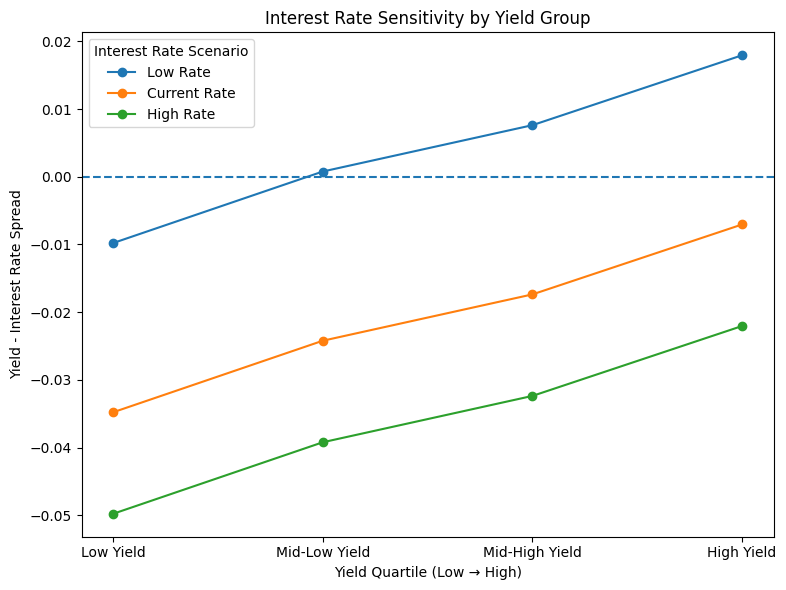

In [32]:
plt.figure(figsize=(8,6))

for col in ["spread_low_rate", "spread_current_rate", "spread_high_rate"]:
    plt.plot(
        spread_by_yield_group["yield_quartile"],
        spread_by_yield_group[col],
        marker="o",
        label=col.replace("spread_", "").replace("_", " ").title()
    )

plt.axhline(0, linestyle="--")
plt.xlabel("Yield Quartile (Low → High)")
plt.ylabel("Yield - Interest Rate Spread")
plt.title("Interest Rate Sensitivity by Yield Group")
plt.legend(title="Interest Rate Scenario")
plt.tight_layout()
plt.show()

**Interpretation**

Low yield suburbs experience the largest negative yield-interest rate spreads across all interest rate scenarios, indicating that rental income is insufficient to cover borrowing costs under relatively low-rate conditions. As interest rates rise, these income shortfalls widen significantly, highlighting increased cash-flow risk in low-yield, premium-priced markets. 

### **Insights 4**: Rental demand conditions vary significantly across Melbourne LGAs

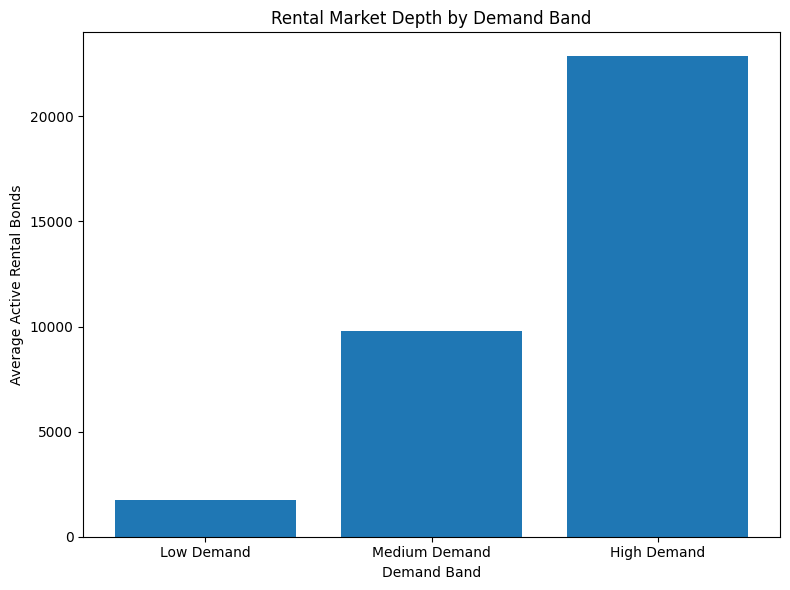

In [33]:
#average active rental bonds by demand band from band_summary 

plt.figure(figsize=(8,6))
plt.bar(band_summary["Demand Band"], band_summary["Average Active Bonds"])

plt.xlabel("Demand Band")
plt.ylabel("Average Active Rental Bonds")
plt.title("Rental Market Depth by Demand Band")
plt.tight_layout()
plt.show()

In [34]:
band_summary

,Demand Band,Average Gross Yield (%),Average Active Bonds,Number of LGAs
0,Low Demand,4.48,1759,14
1,Medium Demand,3.63,9802,13
2,High Demand,2.99,22857,14


**Interpretation**

Rental demand conditions vary substantially across Melbourne LGAs, as reflected by large differences in active rental bond counts between demand bands in the bar chart. High demand areas exhibit significantly deeper rental lmarkets, with average active bonds exceeding 22,000 per LGA, while low-demand areas show materially thinner markets with fewer than 2,000 active bonds on average. 

These differences highlight that vacancy risk is not evenly distributed across Melbourne. While higher-yield areas may offer stronger income returns, they are more exposed to demand volatility and potential vacancy risks. Conversely, high-demand areas provide greater rental stability despite lower yields, reinforcing the importance of incorporating demand metrics alongside yield and financing considerations in property investment decisions. 

### **Insight 5**: No single metric defines an ideal investment suburb 

| Investment Dimension | Strength | Trade-off |
|--------------------|----------|-----------|
| High Yield Areas | Strong rental income | Weaker demand, higher vacancy risk |
| High Demand Areas | Rental stability | Lower income yield |
| Rate-Resilient Areas | Better cash-flow under higher rates | Often mid-yield, not top income |
| Balanced Suburbs | Moderate yield and demand | No single metric dominates |

**Interpretation**

This project demonstrates that no single metric is sufficient to identify an ideal investment suburb. 

High-yield areas offer stronger income returns but tend to exhibit weaker demand conditions and greater exposure to vacancy risk. In contrast, high-demand areas provide rental stability and depth but at the cost of lower income yields and heightened sensitivity to macroeconomic conditions (interest rate increases).

Suburbs that perform reasonably well across multiple dimensions—moderate yields, solid demand, and manageable rate sensitivity—may offer more balanced risk–return profiles. 

Ultimately, investment suitability depends on individual objectives, financing structure, and risk tolerance, reinforcing the importance of a multi-factor approach when evaluating residential property investments.